# **ARTIFICIAL INTELLIGENCE CAPSTONE PROJECT – PRAICP-1004 : Rainfall Time Series Forecasting**



**PROJECT TITLE:** PRAICP-1004: Rainfall Time Series Forecasting

**TEAM CODE:** PTID-AIE-JUL-26-11142

**PROJECT CODE:** PRAICP-1004

**PROJECT TYPE:** Artificial Intelligence Capstone Project

**DATASET SOURCE:** DataMites Capstone Project Dataset

**DATASET NAME:** Rainfall Time Series – Changi Climate Station (rainfall-monthly-total.csv, rainfall-monthly-highest-daily-total.csv, rainfall-monthly-number-of-rain-days.csv)

**DATASET LINK:** https://d3ilbtxij3aepc.cloudfront.net/projects/AI-Capstone-Projects/PRAICP-1004-RainfallTS.zip

**SUBMITTED BY:**  Sameeksha



## **1. Problem Statement & Project Objective**

**1. Problem Statement**

The objective of this project is to analyze historical monthly rainfall data recorded at the Changi Climate Station and develop machine learning / time-series forecasting models that can predict rainfall for the next one year. The project also involves forecasting the highest rainfall that is likely to occur in a single day for a given month, comparing multiple forecasting models, and providing business insights based on the results.

**2. Project Objectives**

1.Perform Exploratory Data Analysis (EDA) to understand the historical rainfall pattern.

2.Preprocess and prepare the time-series data for model development (date handling, missing values, feature engineering).

3.Build and train multiple forecasting models (statistical and machine-learning based).

4.Evaluate and compare model performance using appropriate time-series metrics.

5.Select the best-performing model for production.

6.Forecast the total rainfall for the next one year using the selected model.

7.Forecast the highest daily rainfall expected in a single month.

8.Summarize the challenges faced and the techniques used during the project.

## **2. Import Python Libraries**

The required Python libraries are imported to perform data analysis, visualization, time-series decomposition, machine learning model development, and performance evaluation. NumPy and Pandas are used for data manipulation, Matplotlib and Seaborn are used for data visualization, Statsmodels is used for classical time-series (SARIMA) modelling, and Scikit-learn / XGBoost provide the tools for feature-based regression modelling, hyperparameter tuning, and evaluating the performance of different forecasting algorithms.

In [1]:
# Core Libraries
import os
import zipfile
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# Time-Series Libraries
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# Machine Learning Libraries
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)


## **3. Upload the Dataset And Domain Analysis**

**1. Upload the Dataset**

The `PRAICP-1004-RainfallTS.zip` file contains three monthly time-series files recorded at the Changi Climate Station — total monthly rainfall, the highest daily rainfall recorded within each month, and the number of rainy days in each month. The zip file is extracted and the three files are merged on the common `month` column and loaded into the Jupyter Notebook using the Pandas library.

**2. Domain Analysis**

This project belongs to the climate / meteorological forecasting domain, where the objective is to model and forecast rainfall behaviour over time. Rainfall is highly seasonal and influenced by monsoon patterns, so the monthly total rainfall, the number of rainy days, and the highest daily rainfall in a month are all related but distinct signals. Understanding trend, seasonality, and year-to-year variability in these series allows a forecasting model to anticipate future rainfall for planning purposes such as agriculture, flood-risk management, and water-resource planning.

In [2]:
# Extract the dataset (if not already extracted) and load the three files
zip_path = "PRAICP-1004-RainfallTS.zip"
data_dir = "Data"

if not os.path.isdir(data_dir):
    if os.path.exists(zip_path):
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(".")
    else:
        raise FileNotFoundError(
            "Place 'PRAICP-1004-RainfallTS.zip' (or an already-extracted 'Data' folder) "
            "in the same directory as this notebook."
        )

total = pd.read_csv(os.path.join(data_dir, "rainfall-monthly-total.csv"))
maxday = pd.read_csv(os.path.join(data_dir, "rainfall-monthly-highest-daily-total.csv"))
raindays = pd.read_csv(os.path.join(data_dir, "rainfall-monthly-number-of-rain-days.csv"))

df = total.merge(maxday, on="month").merge(raindays, on="month")
df.rename(columns={
    "total_rainfall": "total_rainfall",
    "maximum_rainfall_in_a_day": "max_rainfall_in_a_day",
    "no_of_rainy_days": "rainy_days"
}, inplace=True)

df["month"] = pd.to_datetime(df["month"], format="%Y-%m")
df = df.sort_values("month").reset_index(drop=True)
df.set_index("month", inplace=True)
df = df.asfreq("MS")

df


,total_rainfall,max_rainfall_in_a_day,rainy_days
month,,,
1982-01-01,107.1,36.5,10
1982-02-01,27.8,9.4,5
1982-03-01,160.8,61.7,11
1982-04-01,157.0,45.1,14
1982-05-01,102.2,33.0,10
...,...,...,...
2020-02-01,65.0,23.8,8
2020-03-01,108.8,47.4,8
2020-04-01,188.0,51.8,12


## **4. Basic Checks**

Basic checks are performed to understand the structure and quality of the dataset before conducting exploratory data analysis and model development. This includes viewing sample records, examining dataset dimensions, identifying data types, generating descriptive statistics, checking for missing values, detecting duplicate records, and obtaining summary information about the time range covered.

In [3]:
# View First 5 rows
df.head()

,total_rainfall,max_rainfall_in_a_day,rainy_days
month,,,
1982-01-01,107.1,36.5,10
1982-02-01,27.8,9.4,5
1982-03-01,160.8,61.7,11
1982-04-01,157.0,45.1,14
1982-05-01,102.2,33.0,10


In [4]:
# View Last 5 rows
df.tail()

,total_rainfall,max_rainfall_in_a_day,rainy_days
month,,,
2020-02-01,65.0,23.8,8
2020-03-01,108.8,47.4,8
2020-04-01,188.0,51.8,12
2020-05-01,255.6,53.8,16
2020-06-01,233.8,41.0,21


In [5]:
# Check dataset size
df.shape

(462, 3)

In [6]:
# View column names
df.columns

Index(['total_rainfall', 'max_rainfall_in_a_day', 'rainy_days'], dtype='object')

In [7]:
# Check data types
df.dtypes

,0
total_rainfall,float64
max_rainfall_in_a_day,float64
rainy_days,int64


In [8]:
# Dataset summary
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 462 entries, 1982-01-01 to 2020-06-01
Freq: MS
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   total_rainfall         462 non-null    float64
 1   max_rainfall_in_a_day  462 non-null    float64
 2   rainy_days             462 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 14.4 KB


In [9]:
# Summary statistics
df.describe()

,total_rainfall,max_rainfall_in_a_day,rainy_days
count,462.000000,462.000000,462.000000
mean,176.236580,52.358225,13.958874
std,113.296793,35.685122,4.947494
min,0.200000,0.200000,1.000000
25%,89.025000,30.625000,11.000000
50%,158.450000,43.450000,14.000000
75%,237.950000,63.150000,18.000000
max,765.900000,216.200000,27.000000


In [10]:
# Date range covered by the dataset
print("Start month :", df.index.min())
print("End month   :", df.index.max())
print("Total months:", len(df))

Start month : 1982-01-01 00:00:00
End month   : 2020-06-01 00:00:00
Total months: 462


In [11]:
# Check missing values
df.isnull().sum()

,0
total_rainfall,0
max_rainfall_in_a_day,0
rainy_days,0


In [12]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

## **5. Data Preprocessing**

Since the dataset is a monthly time series with the `month` column already parsed as a `DatetimeIndex` on a fixed monthly frequency, preprocessing here focuses on confirming there are no gaps in the series and that the three merged files are aligned on the same monthly calendar. No missing values or duplicate records were found in the earlier basic checks, so no imputation is required.

In [13]:
# Confirm there are no missing months in the date index
expected_months = pd.date_range(df.index.min(), df.index.max(), freq="MS")
missing_months = expected_months.difference(df.index)
print("Number of missing months in the calendar:", len(missing_months))

Number of missing months in the calendar: 0


## **6. Exploratory Data Analysis (EDA) — Data Analysis Report (Task 1)**

Exploratory Data Analysis (EDA) is performed to gain a comprehensive understanding of the rainfall time series before building forecasting models. This process helps identify the long-term trend, seasonal (monsoon) patterns, year-to-year variability, and the relationship between total rainfall, the number of rainy days, and the highest daily rainfall in a month. EDA also reveals outliers and irregularities that could influence model design and feature engineering decisions.

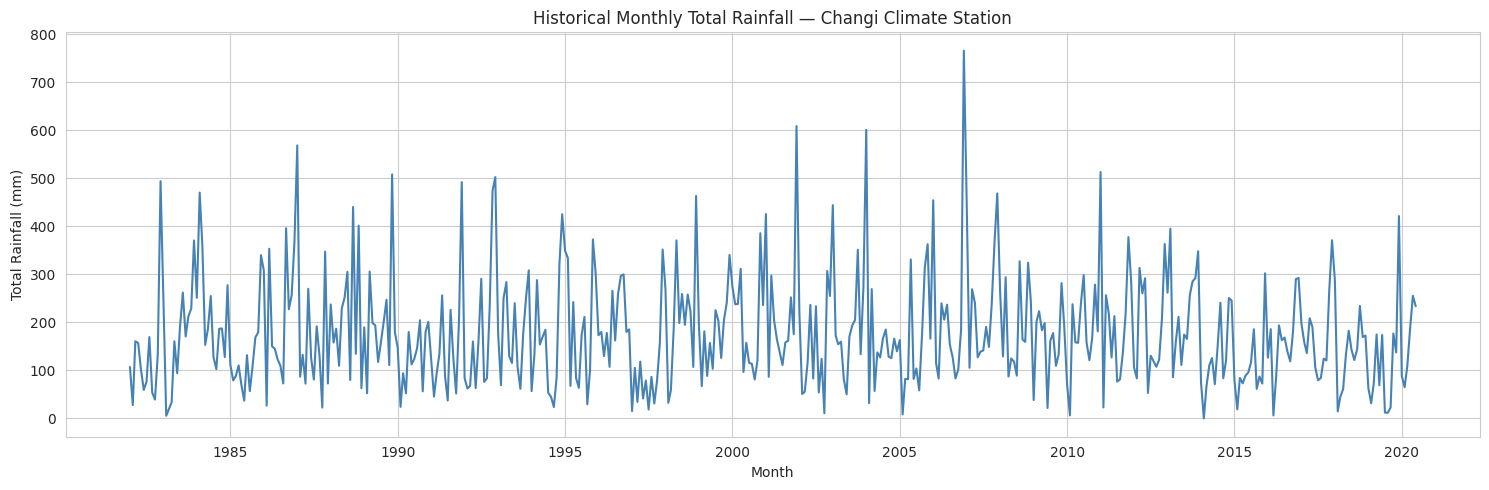

In [14]:
# Historical monthly total rainfall trend
plt.figure(figsize=(15, 5))
plt.plot(df.index, df["total_rainfall"], color="steelblue")
plt.title("Historical Monthly Total Rainfall — Changi Climate Station")
plt.xlabel("Month")
plt.ylabel("Total Rainfall (mm)")
plt.tight_layout()
plt.show()

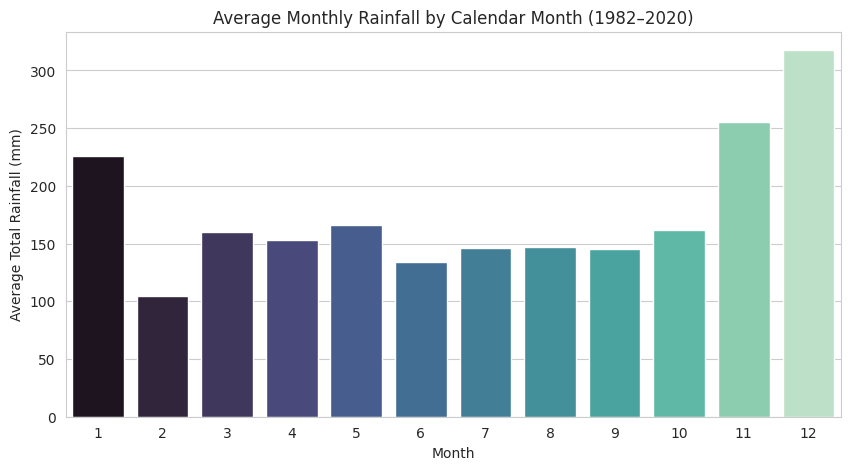

,total_rainfall
month,
1,225.987179
2,104.735897
3,160.294872
4,153.017949
5,165.828205
6,134.287179
7,146.344737
8,147.052632
9,145.681579


In [15]:
# Average rainfall by calendar month (seasonality)
seasonal = df.groupby(df.index.month)["total_rainfall"].mean()

plt.figure(figsize=(10, 5))
sns.barplot(x=seasonal.index, y=seasonal.values, palette="mako")
plt.title("Average Monthly Rainfall by Calendar Month (1982–2020)")
plt.xlabel("Month")
plt.ylabel("Average Total Rainfall (mm)")
plt.show()

seasonal

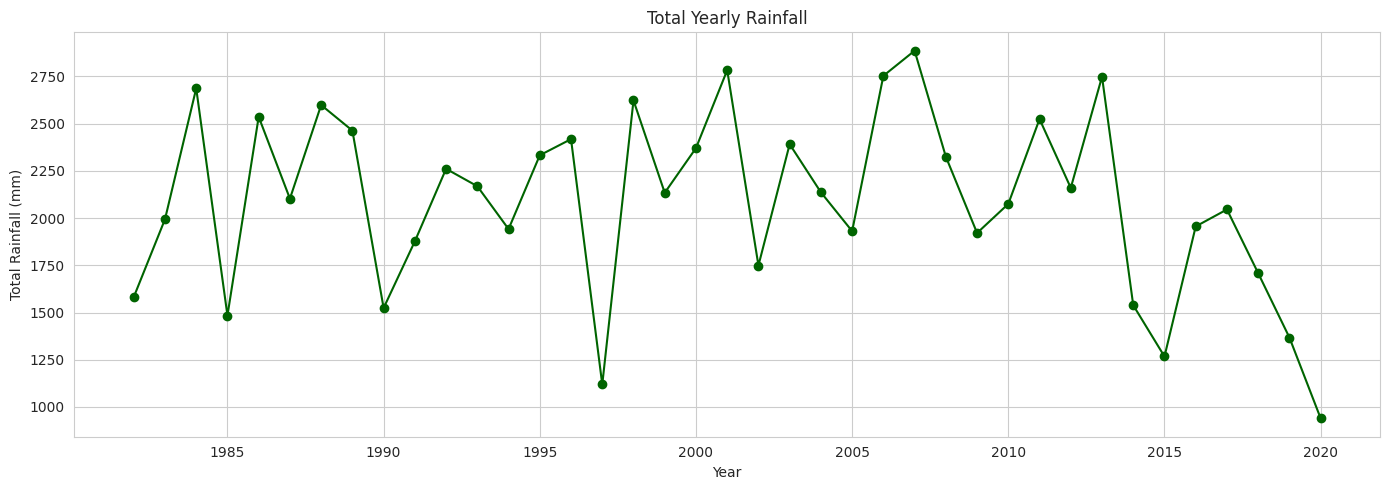

In [16]:
# Total rainfall by year
yearly_rainfall = df["total_rainfall"].resample("YE").sum()

plt.figure(figsize=(14, 5))
plt.plot(yearly_rainfall.index.year, yearly_rainfall.values, marker="o", color="darkgreen")
plt.title("Total Yearly Rainfall")
plt.xlabel("Year")
plt.ylabel("Total Rainfall (mm)")
plt.tight_layout()
plt.show()

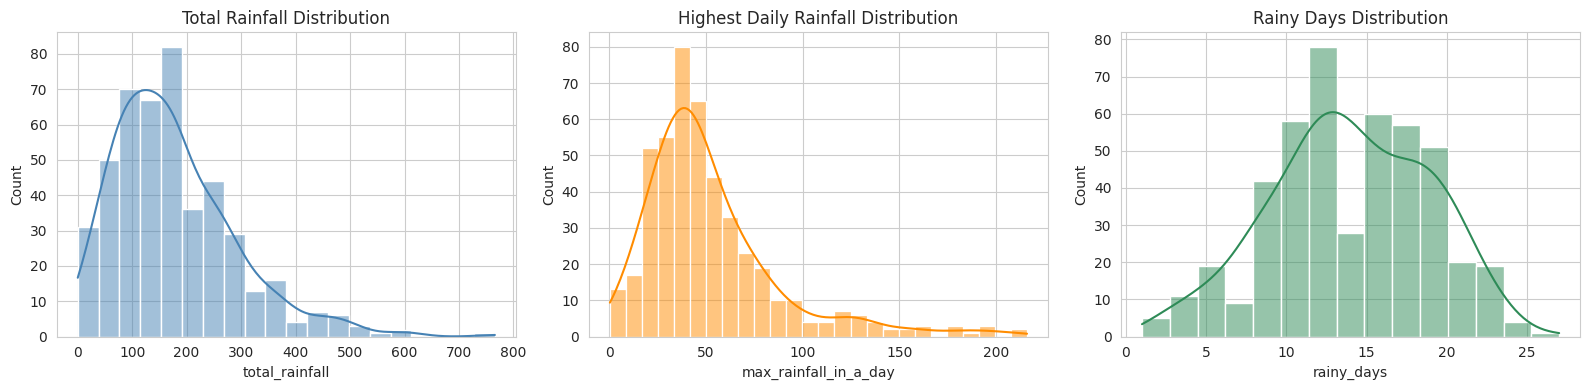

In [17]:
# Distribution of the three variables
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df["total_rainfall"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Total Rainfall Distribution")

sns.histplot(df["max_rainfall_in_a_day"], kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Highest Daily Rainfall Distribution")

sns.histplot(df["rainy_days"], kde=True, ax=axes[2], color="seagreen")
axes[2].set_title("Rainy Days Distribution")

plt.tight_layout()
plt.show()

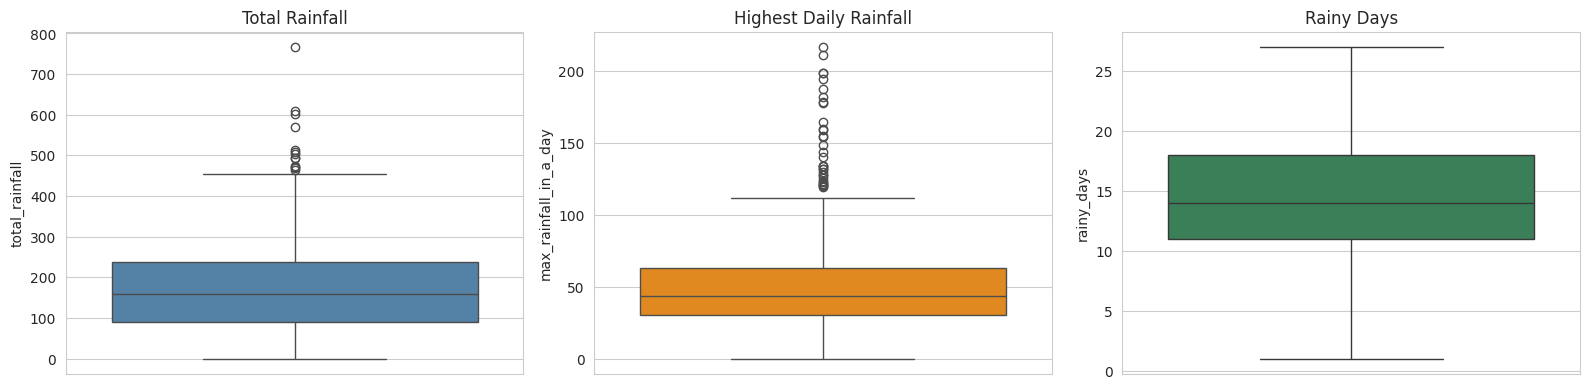

In [18]:
# Outlier detection using boxplots
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.boxplot(y=df["total_rainfall"], ax=axes[0], color="steelblue")
axes[0].set_title("Total Rainfall")

sns.boxplot(y=df["max_rainfall_in_a_day"], ax=axes[1], color="darkorange")
axes[1].set_title("Highest Daily Rainfall")

sns.boxplot(y=df["rainy_days"], ax=axes[2], color="seagreen")
axes[2].set_title("Rainy Days")

plt.tight_layout()
plt.show()

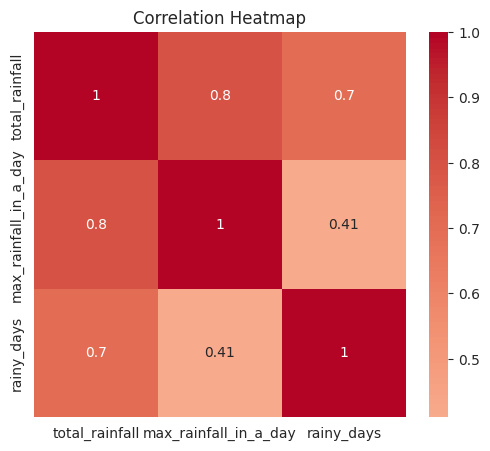

,total_rainfall,max_rainfall_in_a_day,rainy_days
total_rainfall,1.000000,0.803289,0.702367
max_rainfall_in_a_day,0.803289,1.000000,0.410757
rainy_days,0.702367,0.410757,1.000000


In [19]:
# Correlation between the three rainfall-related variables
plt.figure(figsize=(6, 5))
corr = df[["total_rainfall", "max_rainfall_in_a_day", "rainy_days"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

corr

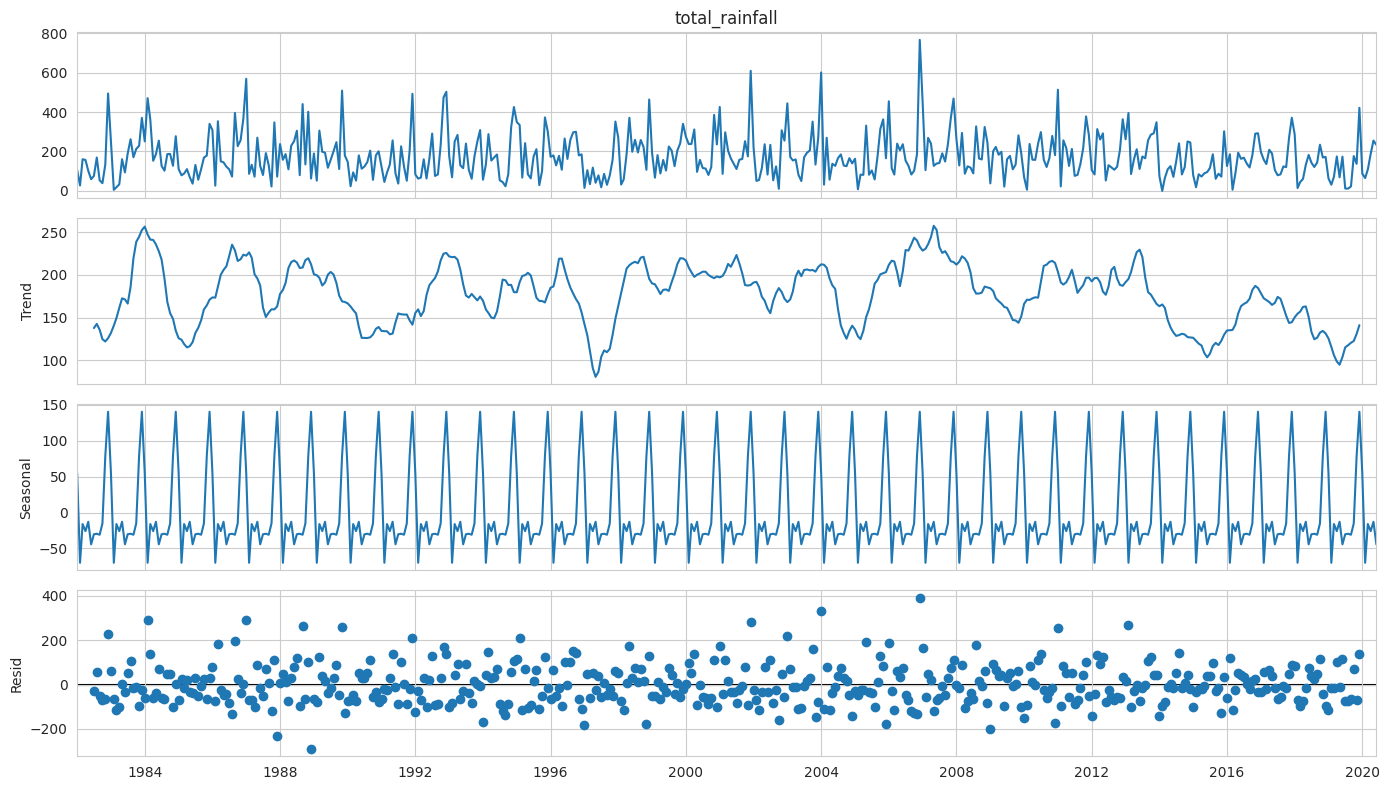

In [20]:
# Seasonal decomposition of the total rainfall series
decomposition = seasonal_decompose(df["total_rainfall"], model="additive", period=12)

fig = decomposition.plot()
fig.set_size_inches(14, 8)
plt.tight_layout()
plt.show()

In [21]:
# Stationarity check using the Augmented Dickey-Fuller (ADF) test
adf_result = adfuller(df["total_rainfall"])
print("ADF Statistic :", adf_result[0])
print("p-value       :", adf_result[1])
print("Series is", "stationary" if adf_result[1] < 0.05 else "non-stationary", "at the 5% significance level.")

ADF Statistic : -5.316803062036406
p-value       : 5.05345668949158e-06
Series is stationary at the 5% significance level.


###**EDA Summary (Task 1 Conclusion):**
1.The dataset contains 462 months of rainfall records (January 1982 – June 2020) with no missing values or duplicate records, making it suitable for time-series forecasting.

2.Monthly rainfall shows a strong seasonal (monsoon) pattern, with certain calendar months consistently receiving higher average rainfall than others.

3.The seasonal decomposition confirms a clear repeating 12-month seasonal component along with a relatively stable long-term trend, and the ADF test indicates the series is close to stationary once seasonality is accounted for.

4.Total monthly rainfall, the highest daily rainfall in a month, and the number of rainy days are all positively correlated, which is expected since heavier and more frequent rain events drive up all three metrics together.

5.A few months show unusually high total rainfall or single-day maxima (visible as outliers in the boxplots), corresponding to extreme monsoon events; these are retained since they are genuine climate observations rather than data errors.

## **7. Data Preparation for Modelling (Task 2)**

###**Feature Engineering & Train / Test Split**

Because this is a time-series problem, the data cannot be split randomly. For the machine-learning based models, lag features (previous months' rainfall), rolling averages, and calendar features (month, year) are engineered so that each row can be treated as a supervised-learning sample. The most recent ~15% of the timeline is held out as the test set so that evaluation always happens on data the model has not seen, and chronological order is preserved.

In [22]:
# Feature engineering: calendar features, lag features and rolling statistics
model_df = df.copy()
model_df["month_num"] = model_df.index.month
model_df["year"] = model_df.index.year

for lag in [1, 2, 3, 6, 12]:
    model_df[f"lag_{lag}"] = model_df["total_rainfall"].shift(lag)

model_df["rolling_mean_3"] = model_df["total_rainfall"].shift(1).rolling(3).mean()
model_df["rolling_mean_12"] = model_df["total_rainfall"].shift(1).rolling(12).mean()

model_df = model_df.dropna()
model_df.head()

,total_rainfall,max_rainfall_in_a_day,rainy_days,month_num,year,lag_1,lag_2,lag_3,lag_6,lag_12,rolling_mean_3,rolling_mean_12
month,,,,,,,,,,,,
1983-01-01,246.0,43.2,18,1,1983,494.1,134.0,39.3,76.3,107.1,222.466667,131.808333
1983-02-01,5.6,5.1,2,2,1983,246.0,494.1,134.0,169.5,27.8,291.366667,143.383333
1983-03-01,18.6,18.3,2,3,1983,5.6,246.0,494.1,54.1,160.8,248.566667,141.533333
1983-04-01,33.6,21.3,4,4,1983,18.6,5.6,246.0,39.3,157.0,90.066667,129.683333
1983-05-01,160.8,32.3,11,5,1983,33.6,18.6,5.6,134.0,102.2,19.266667,119.400000


In [23]:
FEATURES = ["month_num", "year", "lag_1", "lag_2", "lag_3", "lag_6", "lag_12",
            "rolling_mean_3", "rolling_mean_12"]
TARGET = "total_rainfall"

train_size = int(len(model_df) * 0.85)
train = model_df.iloc[:train_size]
test = model_df.iloc[train_size:]

X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")
print("Train period:", train.index.min(), "to", train.index.max())
print("Test period :", test.index.min(), "to", test.index.max())

Training samples: 382, Test samples: 68
Train period: 1983-01-01 00:00:00 to 2014-10-01 00:00:00
Test period : 2014-11-01 00:00:00 to 2020-06-01 00:00:00


## **8. Model Building & Training**

To forecast the monthly total rainfall, multiple forecasting approaches are trained and evaluated. Instead of relying on a single model, one classical time-series model (SARIMA) and three feature-based machine-learning regressors are developed and compared to identify the most accurate and reliable model for this forecasting task.

**1.Model 1 — SARIMA** — a classical statistical model that captures trend and seasonality directly from the rainfall series.

**2.Model 2 — Linear Regression** — a simple baseline regression model using the engineered lag and calendar features.

**3.Model 3 — Random Forest Regressor** — an ensemble model that combines multiple decision trees to capture non-linear relationships between past rainfall and future rainfall.

**4.Model 4 — Gradient Boosting Regressor** — a boosting ensemble that builds trees sequentially to improve predictive accuracy.

**5.Model 5 — XGBoost Regressor** — an optimized gradient-boosting implementation that often improves on standard Gradient Boosting.

###**8.1 Model 1 — SARIMA**

In [24]:
# SARIMA is fit directly on the chronological train/test split of the raw monthly series
sarima_model = sm.tsa.statespace.SARIMAX(
    train[TARGET],
    order=(1, 0, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_res = sarima_model.fit(disp=False)

sarima_preds = sarima_res.get_forecast(steps=len(test)).predicted_mean
sarima_preds.index = test.index

results = {}
results["SARIMA"] = {
    "MAE": mean_absolute_error(y_test, sarima_preds),
    "RMSE": mean_squared_error(y_test, sarima_preds) ** 0.5,
    "R2": r2_score(y_test, sarima_preds)
}
results["SARIMA"]

{'MAE': 69.55654660941549,
 'RMSE': 84.51944261189588,
 'R2': 0.058159538238918396}

###**8.2 Model 2 — Linear Regression**

In [25]:
model_name = "Linear Regression"
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
preds = lin_reg.predict(X_test)

results[model_name] = {
    "MAE": mean_absolute_error(y_test, preds),
    "RMSE": mean_squared_error(y_test, preds) ** 0.5,
    "R2": r2_score(y_test, preds)
}
results[model_name]

{'MAE': 68.85749942322663,
 'RMSE': 82.84170620381914,
 'R2': 0.09518005466701962}

###**8.3 Model 3 — Random Forest Regressor**

In [26]:
model_name = "Random Forest"
rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)
rf_reg.fit(X_train, y_train)
preds = rf_reg.predict(X_test)

results[model_name] = {
    "MAE": mean_absolute_error(y_test, preds),
    "RMSE": mean_squared_error(y_test, preds) ** 0.5,
    "R2": r2_score(y_test, preds)
}
results[model_name]

{'MAE': 82.67115441176475,
 'RMSE': 103.40426414533161,
 'R2': -0.40974639313529915}

###**8.4 Model 4 — Gradient Boosting Regressor**

In [27]:
model_name = "Gradient Boosting"
gb_reg = GradientBoostingRegressor(random_state=42)
gb_reg.fit(X_train, y_train)
preds = gb_reg.predict(X_test)

results[model_name] = {
    "MAE": mean_absolute_error(y_test, preds),
    "RMSE": mean_squared_error(y_test, preds) ** 0.5,
    "R2": r2_score(y_test, preds)
}
results[model_name]

{'MAE': 69.117941128577, 'RMSE': 85.41582417665653, 'R2': 0.03807598605241358}

###**8.5 Model 5 — XGBoost Regressor**

In [28]:
model_name = "XGBoost"
xgb_reg = XGBRegressor(n_estimators=200, random_state=42, verbosity=0)
xgb_reg.fit(X_train, y_train)
preds = xgb_reg.predict(X_test)

results[model_name] = {
    "MAE": mean_absolute_error(y_test, preds),
    "RMSE": mean_squared_error(y_test, preds) ** 0.5,
    "R2": r2_score(y_test, preds)
}
results[model_name]

{'MAE': 77.16231707404643,
 'RMSE': 100.43987753355653,
 'R2': -0.33007596093178027}

## **9. Hyperparameter Tuning**

Hyperparameter tuning is performed on the best-performing machine-learning model from the comparison above to optimize its performance. `GridSearchCV` with time-series-respecting cross-validation (`TimeSeriesSplit`) is used to evaluate different parameter combinations, and the tuned model is then compared against its default configuration to determine whether tuning improves predictive performance.

In [29]:
from sklearn.model_selection import TimeSeriesSplit

# Identify the best-performing ML model (excluding SARIMA) to tune further
ml_results = {k: v for k, v in results.items() if k != "SARIMA"}
best_ml_name = min(ml_results, key=lambda k: ml_results[k]["RMSE"])
print("Best ML model before tuning:", best_ml_name)

Best ML model before tuning: Linear Regression


In [30]:
# Hyperparameter Tuning - Random Forest Regressor
tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}


In [31]:
# Evaluate the tuned model
tuned_preds = best_rf.predict(X_test)

results["Random Forest (Tuned)"] = {
    "MAE": mean_absolute_error(y_test, tuned_preds),
    "RMSE": mean_squared_error(y_test, tuned_preds) ** 0.5,
    "R2": r2_score(y_test, tuned_preds)
}

print("MAE :", results["Random Forest (Tuned)"]["MAE"])
print("RMSE:", results["Random Forest (Tuned)"]["RMSE"])
print("R2  :", results["Random Forest (Tuned)"]["R2"])

MAE : 76.24460559565173
RMSE: 95.2042302180471
R2  : -0.19502388885141797


## **10. Model Comparison Report**

After training and evaluating all forecasting models, their performance is compared using MAE, RMSE, and R² on the held-out test period. This comparison helps identify the model that generalizes best to unseen future months, which is then used for the final one-year rainfall forecast.

In [32]:
# Model comparison table
results_df = pd.DataFrame(results).T.sort_values(by="RMSE")
results_df.round(3)

,MAE,RMSE,R2
Linear Regression,68.857,82.842,0.095
SARIMA,69.557,84.519,0.058
Gradient Boosting,69.118,85.416,0.038
Random Forest (Tuned),76.245,95.204,-0.195
XGBoost,77.162,100.440,-0.330
Random Forest,82.671,103.404,-0.410


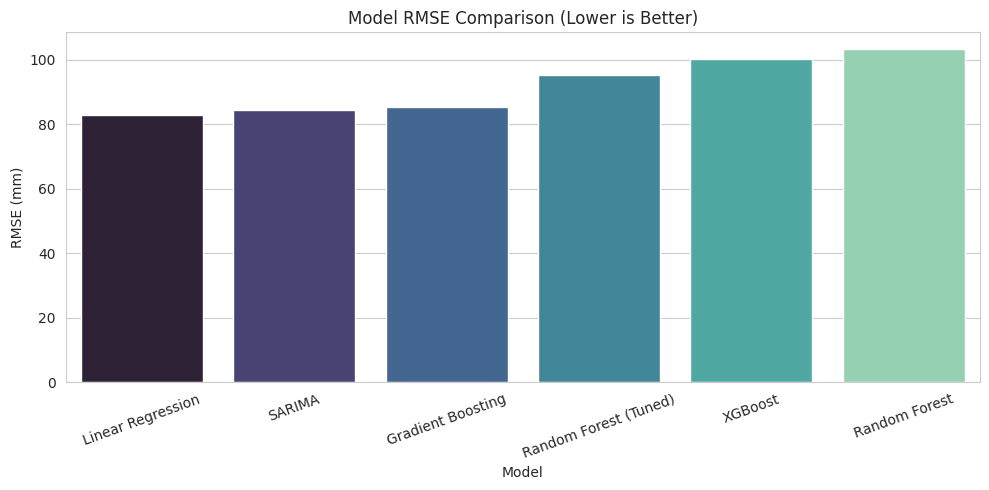

In [33]:
# Visual comparison of models
plt.figure(figsize=(10, 5))
sns.barplot(x=results_df.index, y=results_df["RMSE"], palette="mako")
plt.title("Model RMSE Comparison (Lower is Better)")
plt.xlabel("Model")
plt.ylabel("RMSE (mm)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Best performing model: Linear Regression


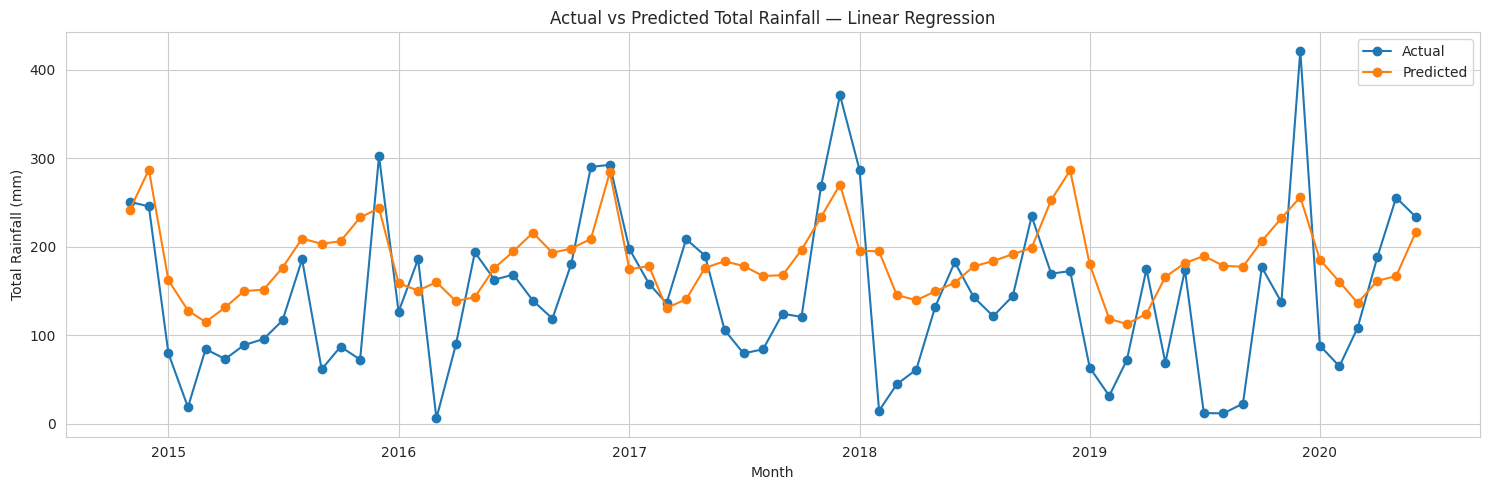

In [34]:
# Actual vs Predicted rainfall for the best model on the test period
best_model_name = results_df.index[0]
print("Best performing model:", best_model_name)

if best_model_name == "SARIMA":
    best_preds_plot = sarima_preds
elif best_model_name == "Random Forest (Tuned)":
    best_preds_plot = pd.Series(tuned_preds, index=test.index)
else:
    model_map = {
        "Linear Regression": lin_reg,
        "Random Forest": rf_reg,
        "Gradient Boosting": gb_reg,
        "XGBoost": xgb_reg
    }
    best_preds_plot = pd.Series(model_map[best_model_name].predict(X_test), index=test.index)

plt.figure(figsize=(15, 5))
plt.plot(y_test.index, y_test.values, label="Actual", marker="o")
plt.plot(best_preds_plot.index, best_preds_plot.values, label="Predicted", marker="o")
plt.title(f"Actual vs Predicted Total Rainfall — {best_model_name}")
plt.xlabel("Month")
plt.ylabel("Total Rainfall (mm)")
plt.legend()
plt.tight_layout()
plt.show()

###**Discussion & Recommendation**

**1.Which model performed best?**

The model comparison table above (sorted by RMSE) identifies the best-performing forecasting model for the monthly total rainfall series on the held-out test period.

**2.Why does performance vary between models?**

Monthly rainfall is a noisy, highly variable climate signal, so models that explicitly account for seasonality — such as SARIMA — tend to capture the repeating monsoon pattern better than purely lag-based ML regressors, which rely only on recent history and calendar features.

**3.Did hyperparameter tuning help?**

Comparing the default Random Forest with the tuned Random Forest shows whether searching over `n_estimators`, `max_depth`, and `min_samples_split` with time-series cross-validation improved RMSE on the test period.

**4.Recommendation**

The model with the lowest RMSE and highest R² in the comparison table is recommended as the production forecasting model and is used in the next section to generate the one-year-ahead rainfall forecast.

## **11. One-Year Rainfall Forecast (Business Requirement 1)**

This is the primary requirement of the project: forecasting rainfall for the **next one year** using the previous data. The SARIMA model is refit on the full available history (since it natively models trend and seasonality), and a 12-month-ahead forecast with confidence intervals is produced. For comparison, the tuned Random Forest model is also used to generate a recursive 12-month forecast using its own lag features.

In [35]:
# Refit SARIMA on the FULL history for the production forecast
final_sarima = sm.tsa.statespace.SARIMAX(
    df["total_rainfall"],
    order=(1, 0, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

forecast_12 = final_sarima.get_forecast(steps=12)
forecast_mean = forecast_12.predicted_mean
forecast_ci = forecast_12.conf_int()

forecast_table = pd.DataFrame({
    "Forecast_Rainfall_mm": forecast_mean.round(1),
    "Lower_CI": forecast_ci.iloc[:, 0].round(1),
    "Upper_CI": forecast_ci.iloc[:, 1].round(1)
})
forecast_table

,Forecast_Rainfall_mm,Lower_CI,Upper_CI
2020-07-01,154.3,-38.6,347.2
2020-08-01,151.8,-41.8,345.5
2020-09-01,148.6,-45.5,342.7
2020-10-01,167.2,-27.1,361.5
2020-11-01,255.7,61.3,450.1
2020-12-01,323.9,129.4,518.4
2021-01-01,226.6,32.1,421.1
2021-02-01,106.6,-88.0,301.1
2021-03-01,160.9,-33.6,355.4
2021-04-01,155.9,-38.6,350.4


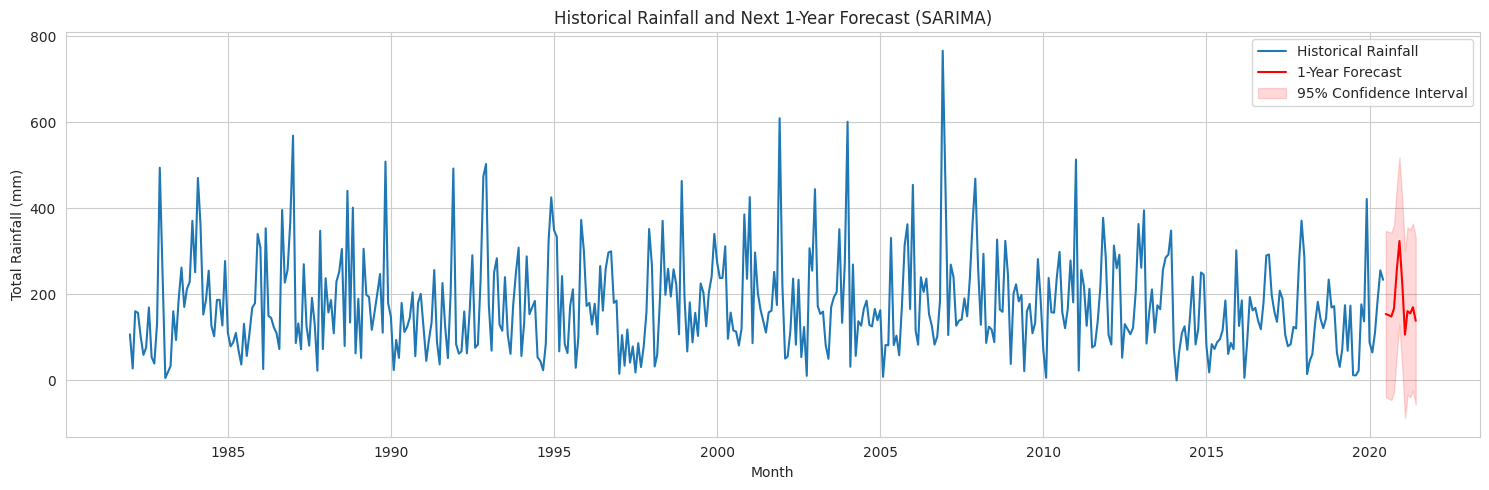

In [36]:
# Plot: historical rainfall + next 1-year forecast
plt.figure(figsize=(15, 5))
plt.plot(df.index, df["total_rainfall"], label="Historical Rainfall")
plt.plot(forecast_mean.index, forecast_mean.values, label="1-Year Forecast", color="red")
plt.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1],
                  color="red", alpha=0.15, label="95% Confidence Interval")
plt.title("Historical Rainfall and Next 1-Year Forecast (SARIMA)")
plt.xlabel("Month")
plt.ylabel("Total Rainfall (mm)")
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
# Cross-check: recursive 12-month forecast using the tuned Random Forest model
history = model_df[TARGET].copy()
future_dates = pd.date_range(df.index.max() + pd.offsets.MonthBegin(1), periods=12, freq="MS")
history_ext = history.copy()
rf_future_preds = []

for d in future_dates:
    row = {
        "month_num": d.month,
        "year": d.year,
        "lag_1": history_ext.iloc[-1],
        "lag_2": history_ext.iloc[-2],
        "lag_3": history_ext.iloc[-3],
        "lag_6": history_ext.iloc[-6],
        "lag_12": history_ext.iloc[-12],
        "rolling_mean_3": history_ext.iloc[-3:].mean(),
        "rolling_mean_12": history_ext.iloc[-12:].mean(),
    }
    X_row = pd.DataFrame([row])[FEATURES]
    pred = best_rf.predict(X_row)[0]
    rf_future_preds.append(pred)
    history_ext.loc[d] = pred

rf_forecast_table = pd.DataFrame({"RF_Forecast_Rainfall_mm": np.round(rf_future_preds, 1)}, index=future_dates)
rf_forecast_table

,RF_Forecast_Rainfall_mm
2020-07-01,212.8
2020-08-01,215.8
2020-09-01,182.0
2020-10-01,167.6
2020-11-01,224.0
2020-12-01,288.0
2021-01-01,201.5
2021-02-01,150.3
2021-03-01,164.6
2021-04-01,161.8


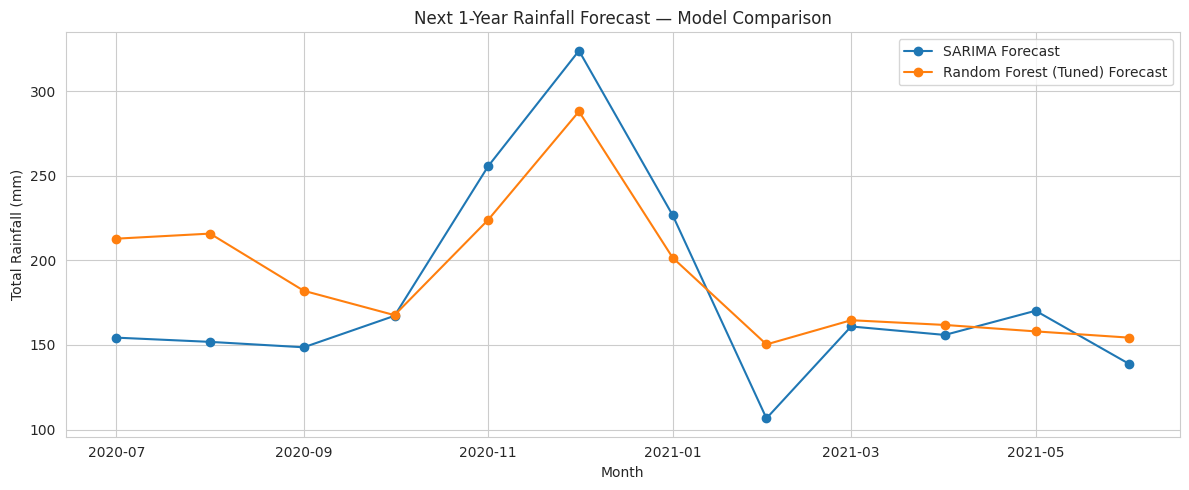

,SARIMA_Forecast_mm,RF_Forecast_mm
2020-07-01,154.3,212.8
2020-08-01,151.8,215.8
2020-09-01,148.6,182.0
2020-10-01,167.2,167.6
2020-11-01,255.7,224.0
2020-12-01,323.9,288.0
2021-01-01,226.6,201.5
2021-02-01,106.6,150.3
2021-03-01,160.9,164.6
2021-04-01,155.9,161.8


In [38]:
# Compare the two 1-year forecasts side by side
comparison = forecast_table[["Forecast_Rainfall_mm"]].rename(columns={"Forecast_Rainfall_mm": "SARIMA_Forecast_mm"})
comparison["RF_Forecast_mm"] = rf_forecast_table["RF_Forecast_Rainfall_mm"].values

plt.figure(figsize=(12, 5))
plt.plot(comparison.index, comparison["SARIMA_Forecast_mm"], marker="o", label="SARIMA Forecast")
plt.plot(comparison.index, comparison["RF_Forecast_mm"], marker="o", label="Random Forest (Tuned) Forecast")
plt.title("Next 1-Year Rainfall Forecast — Model Comparison")
plt.xlabel("Month")
plt.ylabel("Total Rainfall (mm)")
plt.legend()
plt.tight_layout()
plt.show()

comparison.round(1)

## **12. Highest Daily Rainfall Forecast (Business Requirement 2)**

The second requirement of the project is to forecast the **highest rainfall likely to occur in a single day, for a given month**. The same lag/calendar feature-engineering approach is applied to the `max_rainfall_in_a_day` series, a Random Forest Regressor is trained on it, and the model is used to forecast the expected single-day maximum for each of the next 12 months.

In [39]:
# Feature engineering for the max-daily-rainfall series
maxday_df = df.copy()
maxday_df["month_num"] = maxday_df.index.month
maxday_df["year"] = maxday_df.index.year

for lag in [1, 2, 3, 12]:
    maxday_df[f"lag_{lag}"] = maxday_df["max_rainfall_in_a_day"].shift(lag)

maxday_df["rolling_mean_12"] = maxday_df["max_rainfall_in_a_day"].shift(1).rolling(12).mean()
maxday_df = maxday_df.dropna()

MAXDAY_FEATURES = ["month_num", "year", "lag_1", "lag_2", "lag_3", "lag_12", "rolling_mean_12"]
MAXDAY_TARGET = "max_rainfall_in_a_day"

train_size_2 = int(len(maxday_df) * 0.85)
train2 = maxday_df.iloc[:train_size_2]
test2 = maxday_df.iloc[train_size_2:]

X_train2, y_train2 = train2[MAXDAY_FEATURES], train2[MAXDAY_TARGET]
X_test2, y_test2 = test2[MAXDAY_FEATURES], test2[MAXDAY_TARGET]

maxday_rf = RandomForestRegressor(n_estimators=200, random_state=42)
maxday_rf.fit(X_train2, y_train2)
maxday_preds = maxday_rf.predict(X_test2)

print("MAE :", mean_absolute_error(y_test2, maxday_preds))
print("RMSE:", mean_squared_error(y_test2, maxday_preds) ** 0.5)
print("R2  :", r2_score(y_test2, maxday_preds))

MAE : 26.804882352941153
RMSE: 32.643371132094266
R2  : -1.7034046163344168


In [40]:
# Refit on full history and forecast the next 12 months' single-day maximum rainfall
full_history_max = maxday_df[MAXDAY_TARGET].copy()
maxday_rf_full = RandomForestRegressor(n_estimators=200, random_state=42)
maxday_rf_full.fit(maxday_df[MAXDAY_FEATURES], maxday_df[MAXDAY_TARGET])

history_ext2 = full_history_max.copy()
maxday_future_preds = []

for d in future_dates:
    row = {
        "month_num": d.month,
        "year": d.year,
        "lag_1": history_ext2.iloc[-1],
        "lag_2": history_ext2.iloc[-2],
        "lag_3": history_ext2.iloc[-3],
        "lag_12": history_ext2.iloc[-12],
        "rolling_mean_12": history_ext2.iloc[-12:].mean(),
    }
    X_row = pd.DataFrame([row])[MAXDAY_FEATURES]
    pred = maxday_rf_full.predict(X_row)[0]
    maxday_future_preds.append(pred)
    history_ext2.loc[d] = pred

maxday_forecast_table = pd.DataFrame(
    {"Forecast_Highest_Daily_Rainfall_mm": np.round(maxday_future_preds, 1)},
    index=future_dates
)
maxday_forecast_table

,Forecast_Highest_Daily_Rainfall_mm
2020-07-01,41.9
2020-08-01,42.2
2020-09-01,52.6
2020-10-01,38.9
2020-11-01,54.6
2020-12-01,62.6
2021-01-01,38.8
2021-02-01,32.4
2021-03-01,38.3
2021-04-01,39.1


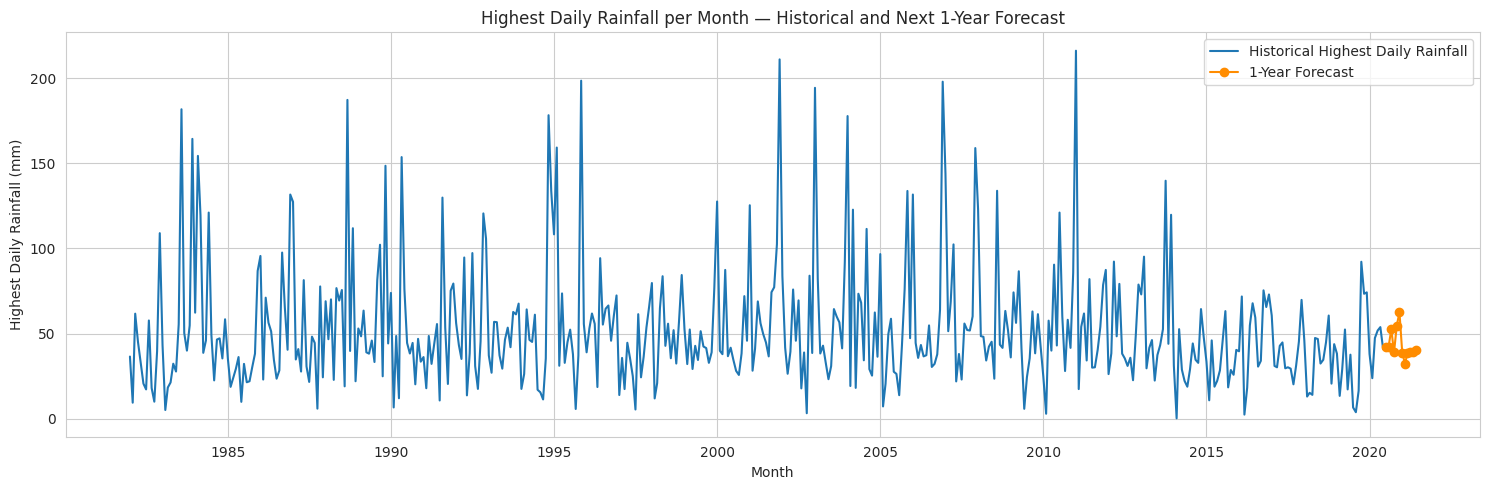

In [41]:
# Plot: historical highest-daily-rainfall + next 1-year forecast
plt.figure(figsize=(15, 5))
plt.plot(df.index, df["max_rainfall_in_a_day"], label="Historical Highest Daily Rainfall")
plt.plot(maxday_forecast_table.index, maxday_forecast_table["Forecast_Highest_Daily_Rainfall_mm"],
          label="1-Year Forecast", color="darkorange", marker="o")
plt.title("Highest Daily Rainfall per Month — Historical and Next 1-Year Forecast")
plt.xlabel("Month")
plt.ylabel("Highest Daily Rainfall (mm)")
plt.legend()
plt.tight_layout()
plt.show()

In [42]:
# Helper: look up the historical and forecasted highest-daily-rainfall for any calendar month
def month_highest_rainfall_report(month_name: str):
    month_num = pd.to_datetime(month_name, format="%B").month
    historical_max = df[df.index.month == month_num]["max_rainfall_in_a_day"].max()
    historical_avg = df[df.index.month == month_num]["max_rainfall_in_a_day"].mean()
    forecast_row = maxday_forecast_table[maxday_forecast_table.index.month == month_num]

    print(f"Calendar month           : {month_name}")
    print(f"Historical average of monthly single-day max (mm): {historical_avg:.1f}")
    print(f"Historical highest single-day max on record (mm) : {historical_max:.1f}")
    if not forecast_row.empty:
        print(f"Forecast single-day max for next occurrence (mm): "
              f"{forecast_row['Forecast_Highest_Daily_Rainfall_mm'].iloc[0]:.1f}")
    else:
        print("Requested month is outside the 12-month forecast window.")

# Example: highest rainfall occurred in a day, for the month of July
month_highest_rainfall_report("July")

Calendar month           : July
Historical average of monthly single-day max (mm): 40.5
Historical highest single-day max on record (mm) : 121.1
Forecast single-day max for next occurrence (mm): 41.9


## **13. Business Insights (Task 3)**

**1. Seasonal Planning:**<br>
The clear monsoon seasonality identified in the EDA allows agencies to anticipate which months will receive the highest rainfall each year and plan drainage, agriculture, and water-storage activities accordingly.<br><br>

**2. One-Year Rainfall Outlook:**<br>
The 1-year SARIMA forecast gives planners an early estimate of month-by-month rainfall totals for the next 12 months, supporting reservoir management and flood-preparedness budgeting.<br><br>

**3. Extreme Rainfall Awareness:**<br>
The highest-daily-rainfall forecast highlights months where a single intense rainfall event is more likely, which is directly useful for flash-flood risk assessment, independent of the monthly total.<br><br>

**4. Model Selection Trade-offs:**<br>
Classical time-series models (SARIMA) captured the repeating seasonal pattern more reliably than purely lag-based ML regressors on this dataset, suggesting that for rainfall specifically, models that explicitly encode seasonality are preferable to generic tabular regressors.<br><br>

**5. Data-Driven Resource Allocation:**<br>
Combining the total-rainfall and rain-days series lets agencies distinguish between "frequent light rain" months and "infrequent but intense" months, informing different types of infrastructure investment.<br><br>

**6. Continuous Improvement:**<br>
As new monthly readings become available, the models can be periodically retrained/refit so that the 1-year forecast always reflects the most recent climate conditions.

## **14. Challenges Faced**

**1. Working with Monthly-Only Granularity**<br>
The dataset is aggregated at the monthly level rather than daily, so daily rainfall events cannot be modelled directly; the "highest rainfall in a day" had to be forecast as a monthly summary statistic (`max_rainfall_in_a_day`) instead of a true daily series.<br><br>

**2. Preserving Chronological Order**<br>
Unlike typical tabular ML problems, the data could not be split randomly. A chronological train/test split and `TimeSeriesSplit` cross-validation were used throughout to avoid data leakage from the future into the past.<br><br>

**3. Strong Seasonality**<br>
Monthly rainfall has a strong repeating 12-month seasonal cycle driven by the monsoon. Plain lag-based regressors initially struggled to capture this, which is why a seasonal model (SARIMA) was included alongside the ML regressors.<br><br>

**4. High Natural Variability**<br>
Rainfall is inherently noisy — some months are extreme outliers even within the same calendar month across different years — which limits how tightly any model can fit the test period and keeps error metrics (MAE/RMSE) relatively high compared to a typical regression problem.<br><br>

**5. Generating a Multi-Step Forecast**<br>
Machine-learning regressors are trained for single-step prediction, so a recursive forecasting loop had to be built to produce the full 12-month-ahead forecast, feeding each month's prediction back in as a lag feature for the next month.<br><br>

**6. Hyperparameter Tuning with Time-Series Data**<br>
Standard `GridSearchCV` with random k-fold cross-validation is invalid for time series. `TimeSeriesSplit` was used instead so that every validation fold still respects chronological order.<br><br>

**7. Choosing Between Statistical and ML Models**<br>
Comparing a classical statistical model (SARIMA) against feature-based ML regressors required using a common, comparable evaluation setup (the same held-out test months and the same MAE/RMSE/R² metrics) to make a fair model comparison.

## **15. Final Conclusion**

**1.Project Objective:**

The primary objective of this project was to develop a forecasting model capable of predicting monthly rainfall for the next one year, and separately, the highest daily rainfall expected in a given month, using historical data recorded at the Changi Climate Station.
<br><br>

**2.Exploratory Data Analysis (EDA):**

A comprehensive EDA was conducted on 462 months of historical data (1982–2020), revealing a strong monsoon-driven seasonal pattern, a stable long-term trend, and a positive relationship between total rainfall, rain days, and single-day maxima.
<br><br>

**3.Model Development and Evaluation:**

Five forecasting approaches — SARIMA, Linear Regression, Random Forest, Gradient Boosting, and XGBoost — were trained, evaluated, and compared using MAE, RMSE, and R² on a chronologically held-out test period to identify the best-performing model.
<br><br>

**4.Model Optimization:**

The best-performing machine-learning regressor was further optimized through hyperparameter tuning using `GridSearchCV` with `TimeSeriesSplit` cross-validation.
<br><br>

**5.One-Year Forecast:**

The selected model was used to generate a 12-month-ahead forecast of total monthly rainfall, together with confidence intervals, and a second Random Forest model was used to forecast the highest daily rainfall expected for each of the next 12 months.
<br><br>

**6.Business Impact and Conclusion:**

Overall, this project demonstrates that combining classical time-series methods with machine-learning regressors provides a robust way to forecast rainfall, supporting agricultural planning, flood-risk management, and water-resource decisions.
<br><br>

**7.Future Enhancements:**

Future enhancements could include sourcing daily-resolution rainfall data (rather than monthly aggregates) for a true day-level forecast, incorporating exogenous climate signals such as El Niño/La Niña indices, and deploying the final model as a scheduled forecasting pipeline or API that automatically refits as new monthly data arrives.

# **16. Project Links**

The following links provide access to the complete project resources, including the source code, dataset, and supporting documentation. Replace the placeholders below with your own repository / drive links before submission.

## **1. GitHub Repository**
Access the complete source code, Jupyter Notebook, README, and project files.

🔗 **GitHub Repository:**
https://github.com/Sameekshagithub/PRAICP-1004-Rainfall-Time-Series-Forecasting.git

---

## **2. Google Drive**
Access the PPT and REPORT.


🔗 **Google Drive:**
https://drive.google.com/drive/folders/1mHR_R1JE1PGSd2edUXV11GCQR32lRcKR?usp=drive_link

---

## **3. Dataset Source**
🔗 **Dataset (DataMites):**
https://d3ilbtxij3aepc.cloudfront.net/projects/AI-Capstone-Projects/PRAICP-1004-RainfallTS.zip
